In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats as sp_stats
from scipy.stats import norm
import tqdm
from model import Model
np.random.seed(42)

### General Description
This code aims to test a simple mean reverting strategy using synthetic data generated froma copula based model.
<br>For this studies, 4 stocks from Brazil market were selected (BBDC4, ITUB4, PETR4, VALE3)
<br>Further Detail will be given step by step
<br><br>Detailed implementation of the sampling method is contained in model.py, and the dataset used is in prices_series.csv

In [2]:
model = Model(
    lmbd=0.94
)

In [3]:
model.df_prices.head()

,BBDC4.SA,ITUB4.SA,PETR4.SA,VALE3.SA
Date,,,,
2008-01-02,9.977742,5.561505,8.669652,21.298456
2008-01-03,9.774626,5.456719,8.530139,21.408806
2008-01-04,9.659766,5.495055,8.111607,20.636326
2008-01-07,9.838635,5.495055,7.873439,20.268476
2008-01-08,9.989291,5.546171,8.305923,20.673115


### Historical Data
To serve as base for the study, Adjusted Closing Prices for all trading days since 2008 up to May 13th 2026 will be use
<br>The idea will be to generate new data from the historical, in order to have more evidence to test our strategy.

<Axes: xlabel='Date'>

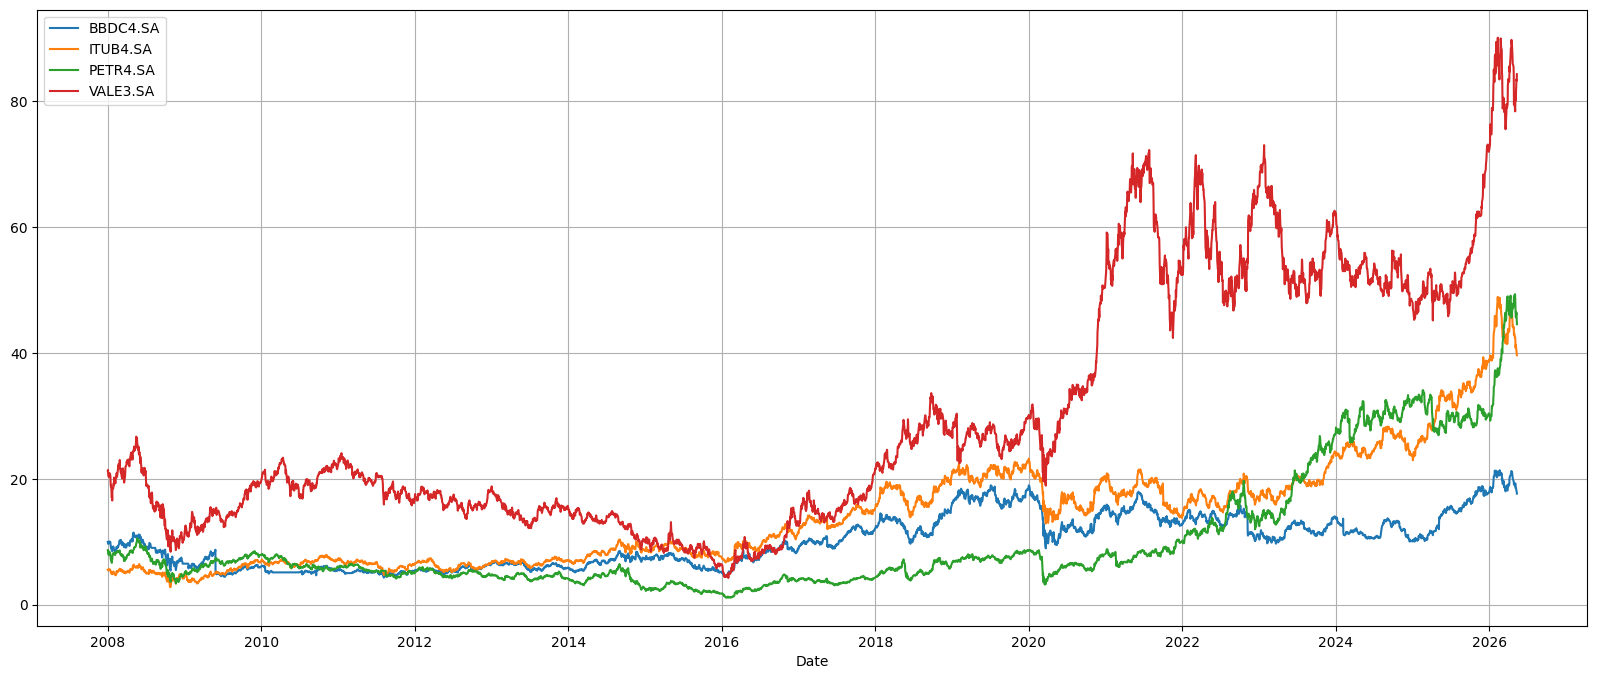

In [4]:
model.df_prices.plot(figsize=(20, 8), grid=True)

### Generate Synthetic Data
In this step the goal will be to generate new future data for all assets, adherent to historical patterns and to the current momentum of each. This will be done via the Gaussian Copula Method. For this study, we'll generate 10_000 paths for 20 days for each one of the four assets. A detailed implementation of the method can be seen in model.py  

In [5]:
NUMBER_OF_PATHS = 10_000
DAYS_FORWARD = 20

In [6]:
generated_returns = model.generate_samples(
    T=DAYS_FORWARD,
    number_of_simulations=NUMBER_OF_PATHS
)
generated_returns.shape # (number of days forward, number of assets, number of simulations)

(20, 4, 10000)

Bellow Chart Shows the Samples obtained for all assets. T + 0 marks current price day. 
<br>The dotted paths represents percentiles 5%, 25%, 50%, 75%, 95%

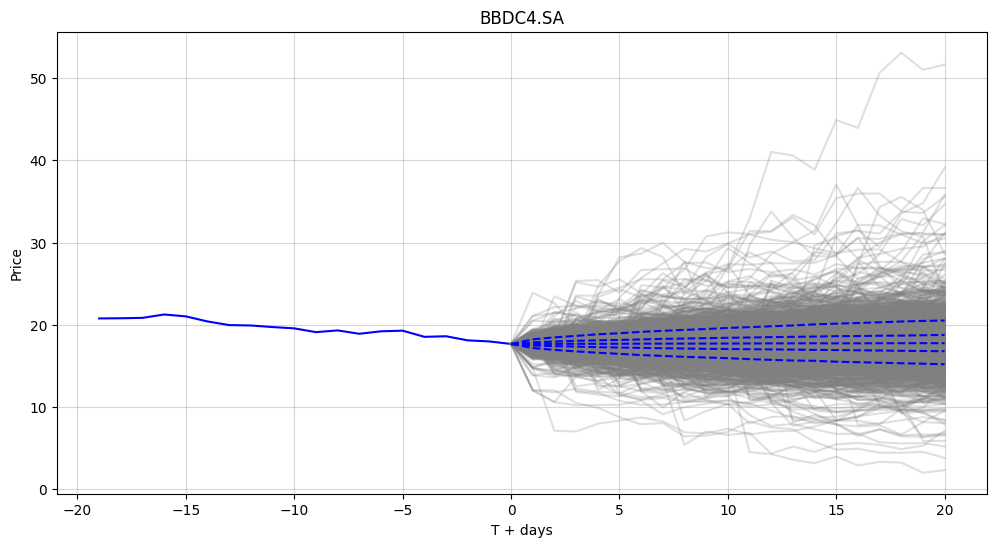

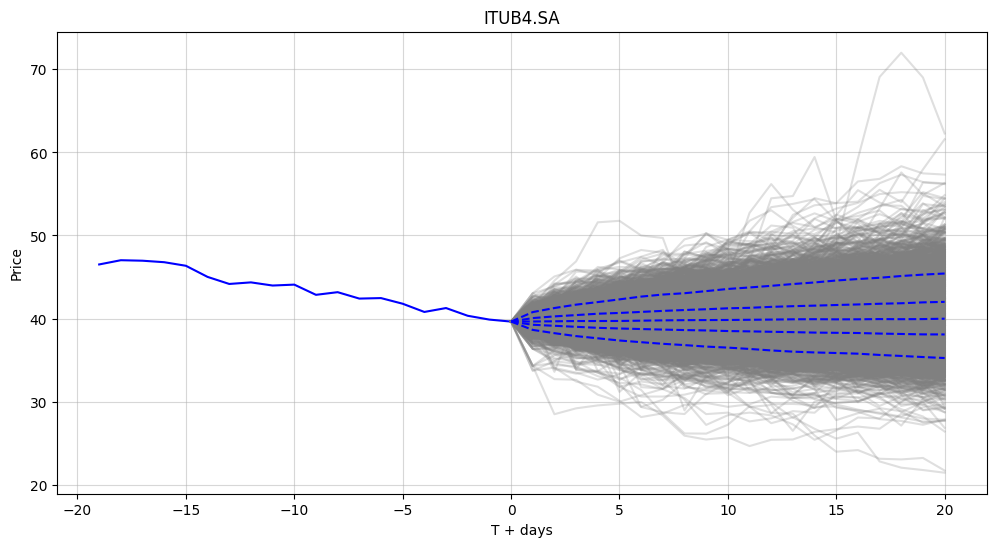

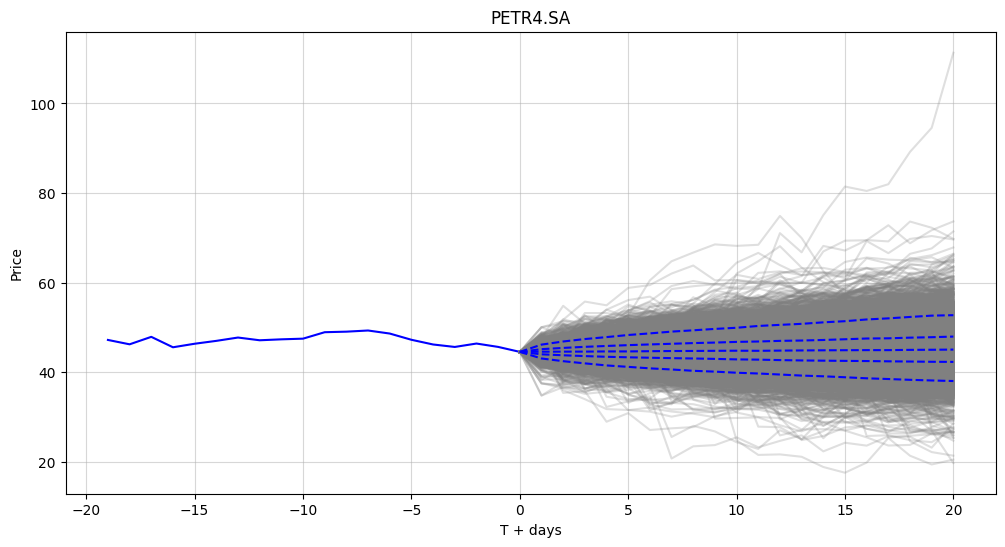

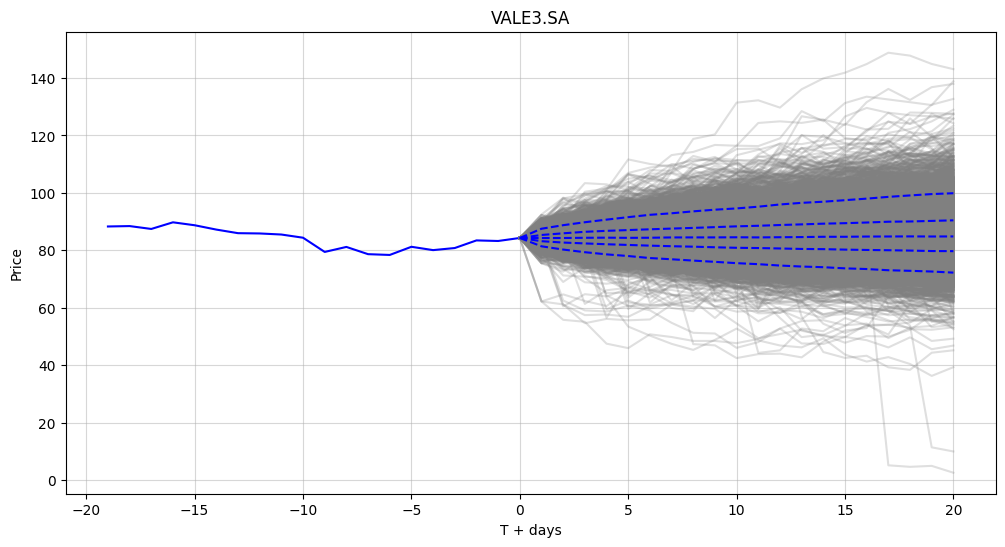

In [7]:
for asset_to_plot in model.assets:
    last_prices_plot = model.df_prices[asset_to_plot].tail(DAYS_FORWARD).copy()
    last_prices_plot.index = list(range(-(DAYS_FORWARD-1), 1, 1))

    prices_simulated_plot = (generated_returns[:, model.assets.index(asset_to_plot)])
    prices_simulated_plot = np.cumprod(prices_simulated_plot+1, axis=0) * last_prices_plot.iloc[-1]
    prices_simulated_plot = np.concatenate(
        [np.tile(last_prices_plot.iloc[-1], (1, NUMBER_OF_PATHS)), prices_simulated_plot]
    )
    plt.figure(figsize=(12, 6))
    plt.title(asset_to_plot)
    plt.plot(last_prices_plot, color='blue')
    plt.plot(prices_simulated_plot, color='grey', alpha=0.25)
    for q in [0.05, 0.25, 0.50, 0.75, 0.95]:
        plt.plot(np.quantile(prices_simulated_plot, q, axis=1), alpha=1, color='blue', linestyle='--')
    plt.grid(True, alpha=0.50)
    plt.ylabel('Price')
    plt.xlabel('T + days')
    plt.show()

### Signal Generation

In [8]:
REVERSION_WINDOW     = 5
HOLDING_PERIOD       = REVERSION_WINDOW   # cumulative return window after signal fires
CONFIDENCE_THRESHOLD = 0.05

# Sum of n IID N(0,1) variables ~ N(0, sqrt(n))
threshold = norm.ppf(CONFIDENCE_THRESHOLD, scale=np.sqrt(REVERSION_WINDOW))
threshold

np.float64(-3.6780045229005736)

In [9]:
generated_signs = []

for sample in tqdm.tqdm(range(NUMBER_OF_PATHS)):

    sim_returns    = generated_returns[:, :, sample]           # (DAYS_FORWARD, n_assets)
    returns_concat = np.vstack([model.df_returns.values, sim_returns])

    vol_ewma = model.get_ewma_vol(returns_concat)              # pass ndarray, not DataFrame
    vol_adj  = returns_concat[-vol_ewma[:-1].shape[0]:] / vol_ewma[:-1]

    rolling_sum = np.lib.stride_tricks.sliding_window_view(
        vol_adj, window_shape=REVERSION_WINDOW, axis=0
    ).sum(axis=-1)

    n_valid = DAYS_FORWARD - REVERSION_WINDOW
    rolling_sum_last = rolling_sum[-n_valid:-HOLDING_PERIOD]

    # day_idx, asset_idx = np.where(rolling_sum_last < threshold)
    mask = rolling_sum_last < threshold
    has_occurrence = mask.any(axis=0)
    asset_idx = np.flatnonzero(has_occurrence)
    day_idx = np.argmax(mask[:, asset_idx], axis=0)

    if len(day_idx):

        day_matrix = day_idx[:, None] + REVERSION_WINDOW +  np.arange(HOLDING_PERIOD) + 1
        fwd_window = sim_returns[day_matrix, asset_idx[:, None]]
        cum_rets   = np.prod(1 + fwd_window, axis=1) - 1

        generated_signs.extend(zip(
            np.full(len(day_idx), sample), asset_idx, day_idx, cum_rets
        ))

100%|██████████| 10000/10000 [00:59<00:00, 169.39it/s]


#### Stationarity Check on Rolling Sum
Before running the simulation, verify that the 5-day rolling sum of vol-adjusted returns (the signal statistic) is stationary on historical data.  
- **ADF** (H₀: unit root) — want to **reject** (p < 0.05)  
- **KPSS** (H₀: stationary) — want to **fail to reject** (p > 0.05)

In [10]:
# Rolling sum on historical data only -- validates the signal statistic before simulation
vol_ewma_hist = model.get_ewma_vol(model.df_returns.values)
vol_adj_hist  = model.df_returns.values[-vol_ewma_hist[:-1].shape[0]:] / vol_ewma_hist[:-1]
rolling_hist  = np.lib.stride_tricks.sliding_window_view(
    vol_adj_hist, window_shape=REVERSION_WINDOW, axis=0
).sum(axis=-1)   # shape (T - REVERSION_WINDOW + 1, n_assets)

# ADF  H0: unit root  -> want to REJECT (p < 0.05)  => stationary
# KPSS H0: stationary -> want to KEEP   (p > 0.05)  => stationary
print(f"{"Asset":<12} {"ADF stat":>10} {"ADF p":>8} {"ADF: reject H0":>15}  {"KPSS stat":>10} {"KPSS p":>8} {"KPSS: keep H0":>14}")
print("-" * 82)
for i, asset in enumerate(model.assets):
    series  = rolling_hist[:, i]
    adf_s,  adf_p  = adfuller(series, autolag="AIC")[:2]
    kpss_s, kpss_p = kpss(series, regression="c", nlags="auto")[:2]
    print(f"{asset:<12} {adf_s:>10.3f} {adf_p:>8.4f} {str(adf_p  < 0.05):>15}  "
          f"{kpss_s:>10.3f} {kpss_p:>8.4f} {str(kpss_p > 0.05):>14}")

C:\Users\Bernardo\AppData\Local\Temp\ipykernel_20460\1447630079.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_s, kpss_p = kpss(series, regression="c", nlags="auto")[:2]
C:\Users\Bernardo\AppData\Local\Temp\ipykernel_20460\1447630079.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_s, kpss_p = kpss(series, regression="c", nlags="auto")[:2]


Asset          ADF stat    ADF p  ADF: reject H0   KPSS stat   KPSS p  KPSS: keep H0
----------------------------------------------------------------------------------
BBDC4.SA        -10.892   0.0000            True       0.062   0.1000           True
ITUB4.SA        -10.517   0.0000            True       0.167   0.1000           True
PETR4.SA        -10.349   0.0000            True       0.631   0.0198          False
VALE3.SA        -10.495   0.0000            True       0.271   0.1000           True


C:\Users\Bernardo\AppData\Local\Temp\ipykernel_20460\1447630079.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_s, kpss_p = kpss(series, regression="c", nlags="auto")[:2]


### Results of the Model

In [11]:
signs_df = pd.DataFrame(generated_signs, columns=['sample', 'asset_idx', 'day_idx', 'cum_return'])
signs_df['asset'] = signs_df['asset_idx'].map(dict(enumerate(model.assets)))

In [12]:
signs_df.groupby("asset")["cum_return"].agg(
    count="count", 
    mean=lambda x: (x*10_000).mean(), 
    std=lambda x: (x*10_000).std(),
    win_rate=lambda x: (x > 0).mean() * 100
).round(2).\
    rename(columns={"count": "Count", "mean": "Mean Return (bps)", "std": "Std Returns (bps)", "win_rate": "Win Rate (T)"})

,Count,Mean Return (bps),Std Returns (bps),Win Rate (T)
asset,,,,
BBDC4.SA,2245,12.81,683.24,50.51
ITUB4.SA,2193,18.32,454.26,50.30
PETR4.SA,2261,61.10,678.80,54.18
VALE3.SA,2237,35.32,590.90,52.26


In [13]:
fwd = signs_df["cum_return"].values

# Unconditional baseline: cumulative HOLDING_PERIOD returns at the same forward horizons
start_days   = np.arange(REVERSION_WINDOW, DAYS_FORWARD - HOLDING_PERIOD + 1)
day_matrix_u = start_days[:, None] + np.arange(HOLDING_PERIOD)    # (n_valid, HP)
# generated_returns shape: (DAYS_FORWARD, n_assets, n_sims)
unconditional = (np.prod(1 + generated_returns[day_matrix_u, :, :], axis=1) - 1).reshape(-1)

print("== OVERALL (all assets combined) ==")
t_stat, p_t   = sp_stats.ttest_1samp(fwd, popmean=0, alternative="greater")
n_pos         = int((fwd > 0).sum())
p_binom       = sp_stats.binomtest(n_pos, len(fwd), p=0.5, alternative="greater").pvalue
print(f"  N Signals         : {len(fwd):,}")
print(f"  Mean Return (bps) : {fwd.mean()*10_000:.2f}")
print(f"  t-test (mean>0)   : t={t_stat:.3f}, p={p_t:.4f}")
print(f"  Win Rate          : {n_pos/len(fwd):.2%}")
print(f"  Binom  (>50%)     : p={p_binom:.4f}")

print("== PER ASSET ==")
for asset in model.assets:
    f = signs_df.loc[signs_df["asset"] == asset, "cum_return"].values
    if not len(f):
        continue
    t, pt = sp_stats.ttest_1samp(f, popmean=0, alternative="greater")
    np_   = int((f > 0).sum())
    pb    = sp_stats.binomtest(np_, len(f), p=0.5, alternative="greater").pvalue
    print(f"  {asset}: n={len(f):,}  mean={f.mean()*10_000:.2f} bps  "
          f"t={t:.2f} (p={pt:.4f})  win={np_/len(f):.1%} (p={pb:.4f})")

== OVERALL (all assets combined) ==
  N Signals         : 8,936
  Mean Return (bps) : 32.02
  t-test (mean>0)   : t=4.961, p=0.0000
  Win Rate          : 51.82%
  Binom  (>50%)     : p=0.0003
== PER ASSET ==
  BBDC4.SA: n=2,245  mean=12.81 bps  t=0.89 (p=0.1872)  win=50.5% (p=0.3212)
  ITUB4.SA: n=2,193  mean=18.32 bps  t=1.89 (p=0.0296)  win=50.3% (p=0.3989)
  PETR4.SA: n=2,261  mean=61.10 bps  t=4.28 (p=0.0000)  win=54.2% (p=0.0000)
  VALE3.SA: n=2,237  mean=35.32 bps  t=2.83 (p=0.0024)  win=52.3% (p=0.0172)
